<a href="https://colab.research.google.com/github/rahul02500/Practicepython/blob/main/M5_Build_a_Financial_Analyst_ReAct_Agentic_AI_System_with_LangChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build a Financial Analyst ReAct Agentic AI System with LangChain

### Building a Financial Analyst ReAct Agentic AI System

In this project, we will design a **Financial Analyst ReAct Agentic AI System** to assist investors by providing accurate and up-to-date stock market insights. This system will leverage the `create_react_agent` function from **LangGraph**, a more robust and modern alternative to the deprecated LangChain version. The workflow comprises the following components:

1. **Agent System Prompt**: The agent is designed to:
   - Validate input queries to ensure they are relevant and specific.
   - Provide detailed market analysis or individual stock insights depending on the user's query.
   - For invalid queries, respond professionally and guide the user appropriately.
   - Deliver concise, accurate, and professional responses while emphasizing data accuracy.

   **Flows**:
   - **Flow 1**: For general market queries, use tools to analyze trends and suggest stock opportunities.
   - **Flow 2**: For stock-specific queries, validate the ticker, retrieve data, and provide insights.

2. **Financial Analysis Tools**: The system utilizes the following tools to interact with stock market data:
   - **GET_STOCK_TICKER**: Validates and fetches stock tickers based on user queries.
   - **GET_STOCK_PRICE_METRICS**: Retrieves price trends and metrics for specific stocks.
   - **GET_STOCK_NEWS**: Extracts recent news articles related to stocks or markets.
   - **GET_STOCK_FUNDAMENTAL_INDICATOR_METRICS**: Provides insights into financial indicators like P/E ratio, ROE, etc.
   - **GET_GENERAL_MARKET_DATA**: Fetches general market trends and data.

3. **Stock Market Data Providers**: The system integrates with leading data providers such as Yahoo Finance, Finviz, Cboe, and others through platforms like __OpenBB__ to ensure reliable and real-time information.

4. **ReAct Reasoning Framework**: The agent employs ReAct reasoning to combine logical deduction with dynamic tool usage, ensuring precise and actionable results.

5. **Final Response**: After processing the data, the agent delivers a well-structured response emphasizing clarity and encouraging users to verify any investment decisions.

By utilizing LangGraph's `create_react_agent` and integrating comprehensive financial data tools, this system empowers investors with actionable insights, enabling informed decision-making in the dynamic stock market environment.

![](https://i.imgur.com/ZbYjVIE.png)

## Install OpenAI, and LangChain and OpenBB dependencies

In [1]:
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.66
!pip install yfinance==0.2.51

  Using cached langchain_openai-0.3.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached openai-1.109.1-py3-none-any.whl.metadata (29 kB)
Using cached langchain_openai-0.3.0-py3-none-any.whl (54 kB)
Using cached openai-1.109.1-py3-none-any.whl (948 kB)
  Attempting uninstall: openai
    Found existing installation: openai 2.45.0
    Uninstalling openai-2.45.0:
      Successfully uninstalled openai-2.45.0
  Using cached langchain_community-0.3.14-py3-none-any.whl.metadata (2.9 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached pydantic_settings-2.14.2-py3-none-any.whl.metadata (3.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 4.1 MB/s et

In [2]:
!pip install openbb[all]

INFO: pip is looking at multiple versions of requests-cache to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.8/99.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.5/125.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.4/111.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 

## Enter Open AI API Key

In [3]:

from google.colab import userdata

# Replace 'OPENAI_API_KEY' with the exact name you used in Colab Secrets
Openai_key = userdata.get('OpenAI')

In [5]:

from google.colab import userdata

OPENBB_PAT = userdata.get('obb')

## Enter OpenBB Personal Access Token

## Setup Environment Variables

In [12]:
import os
os.environ['OPENAI']=Openai_key
os.environ['OPENBB_PAT']=OPENBB_PAT

In [13]:
from openbb import obb
# takes 1 min to setup everything
# obb.user.login(pat=OPENBB_PAT) # No longer needed as PAT is set as environment variable

## Create Financial Data Retrieval Tools

We will create custom tools as following which can be used by our Agentic AI System to interact with stock market data:

   - **GET_STOCK_TICKER**: Validates and fetches stock tickers based on user queries.
   - **GET_STOCK_PRICE_METRICS**: Retrieves price trends and metrics for specific stocks.
   - **GET_STOCK_NEWS**: Extracts recent news articles related to stocks or markets.
   - **GET_STOCK_FUNDAMENTAL_INDICATOR_METRICS**: Provides insights into financial indicators like P/E ratio, ROE, etc.
   - **GET_GENERAL_MARKET_DATA**: Fetches general market trends and data.

   
![](https://i.imgur.com/C9Ay1kv.png)

Refer to the comprehensive [OpenBB Documentation](https://docs.openbb.co/platform/reference) for understanding the specific functions used below in more detail.


In [14]:
from langchain_core.tools import tool
from datetime import datetime, timedelta

@tool
def get_stock_ticker_symbol(stock_name: str) -> str:
    """Get the symbol, name and CIK for any publicly traded company"""
    # Use OpenBB to search for stock ticker symbol and company details by name.
    # The provider "sec" fetches data from the U.S. Securities and Exchange Commission (SEC).
    res = obb.equity.search(stock_name, provider="sec")

    # Convert the result to a DataFrame and format it as markdown for readability.
    stock_ticker_details = res.to_df().to_markdown()

    # Prepare the output with the stock details.
    output = """Here are the details of the company and its stock ticker symbol:\n\n""" + stock_ticker_details
    return output

@tool
def get_stock_price_metrics(stock_ticker: str) -> str:
    """Get historical stock price data, stock price quote and price performance data
       like price changes for a specific stock ticker"""

    # Fetch the latest stock price quote using "cboe" provider.
    res = obb.equity.price.quote(stock_ticker, provider='cboe')
    price_quote = res.to_df().to_markdown()

    # Retrieve stock price performance metrics (e.g., percentage change) using "finviz" provider.
    res = obb.equity.price.performance(symbol=stock_ticker, provider='finviz')
    price_performance = res.to_df().to_markdown()

    # Fetch historical price data for the past year using "yfinance" provider.
    end_date = datetime.now()
    start_date = (end_date - timedelta(days=365)).strftime("%Y-%m-%d")
    res = obb.equity.price.historical(symbol=stock_ticker, start_date=start_date,
                                      interval='1d', provider='yfinance')
    price_historical = res.to_df().to_markdown()

    # Combine the results into a formatted output.
    output = ("""Here are the stock price metrics and data for the stock ticker symbol """ + stock_ticker + """: \n\n""" +
              "Price Quote Metrics:\n\n" + price_quote +
              "\n\nPrice Performance Metrics:\n\n" + price_performance +
              "\n\nPrice Historical Data:\n\n" + price_historical)
    return output

@tool
def get_stock_fundamental_indicator_metrics(stock_ticker: str) -> str:
    """Get fundamental indicator metrics for a specific stock ticker"""

    # Retrieve fundamental financial ratios (e.g., P/E ratio, ROE) using "fmp" provider.
    res = obb.equity.fundamental.ratios(symbol=stock_ticker, period='annual',
                                        limit=10, provider='fmp')
    fundamental_ratios = res.to_df().to_markdown()

    # Fetch additional fundamental metrics (e.g., EBITDA, revenue growth) using "yfinance" provider.
    res = obb.equity.fundamental.metrics(symbol=stock_ticker, period='annual',
                                        limit=10, provider='yfinance')
    fundamental_metrics = res.to_df().to_markdown()

    # Combine fundamental ratios and metrics into a single output.
    output = ("""Here are the fundamental indicator metrics and data for the stock ticker symbol """ + stock_ticker + """: \n\n""" +
              "Fundamental Ratios:\n\n" + fundamental_ratios +
              "\n\nFundamental Metrics:\n\n" + fundamental_metrics)
    return output

@tool
def get_stock_news(stock_ticker: str) -> str:
    """Get news article headlines for a specific stock ticker"""

    # Define the date range to fetch news (last 45 days).
    end_date = datetime.now()
    start_date = (end_date - timedelta(days=45)).strftime("%Y-%m-%d")

    # Retrieve news headlines for the stock using "tmx" provider.
    res = obb.news.company(symbol=stock_ticker, start_date=start_date, provider='tmx', limit=50)
    news = res.to_df()

    # Extract relevant columns (symbols and titles) and format as markdown.
    news = news[['symbols', 'title']].to_markdown()

    # Prepare the output with the news headlines.
    output = ("""Here are the recent news headlines for the stock ticker symbol """ + stock_ticker + """: \n\n""" + news)
    return output

@tool
def get_general_market_data() -> str:
    """Get general data and indicators for the whole stock market including,
       most actively traded stocks based on volume, top price gainers and top price losers.
       Useful when you want an overview of the market and what stocks to look at."""

    # Retrieve the most actively traded stocks using "yfinance" provider.
    res = obb.equity.discovery.active(sort='desc', provider='yfinance', limit=15)
    most_active_stocks = res.to_df().to_markdown()

    # Fetch the top price gainers using "yfinance" provider.
    res = obb.equity.discovery.gainers(sort='desc', provider='yfinance', limit=15)
    price_gainers = res.to_df().to_markdown()

    # Retrieve the top price losers using "yfinance" provider.
    res = obb.equity.discovery.losers(sort='desc', provider='yfinance', limit=15)
    price_losers = res.to_df().to_markdown()

    # Combine the market data into a single formatted output.
    output = ("""Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:\n\n""" +
              "Most actively traded stocks:\n\n" + most_active_stocks +
              "\n\nTop price gainers:\n\n" + price_gainers +
              "\n\nTop price losers:\n\n" + price_losers)
    return output


## Test Tools

In [15]:
from IPython.display import display, Markdown

response = get_general_market_data.invoke({})
display(Markdown(response))

Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:

Most actively traded stocks:

|    | symbol   | name                            |   price |     change |   percent_change |    volume |    open |     high |      low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:--------------------------------|--------:|-----------:|-----------------:|----------:|--------:|---------:|---------:|-----------------:|---------:|----------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | AAL      | American Airlines Group, Inc.   |   14.98 |  -0.620001 |      -0.0397436  | 176722073 |  15.22  |  15.34   |  14.945  |            15.6  |  14.9866 |  13.5625  |       18.79 |      10.09 |  9.90755e+09 |          6.61385e+08 |     -6.164   |        -2.43024 |      0.31 |       2.53025 |      5.92036 |      0           | NMS        | America/New_York    | 2026-07-23 08:30:00-04:00 | USD        |
|  1 | NFLX     | Netflix, Inc.                   |   68.95 |  -5.4      |      -0.0726295  | 141231076 |  65.54  |  69.49   |  65.095  |            74.35 |  80.5618 |  93.7382  |      126.71 |      65.08 |  2.90335e+11 |          4.2108e+09  |      7.389   |         9.33144 |      3.18 |       3.8196  |     18.0516  |      0           | NMS        | America/New_York    | 2026-07-16 16:00:00-04:00 | USD        |
|  2 | NVDA     | NVIDIA Corporation              |  202.81 |  -4.59     |      -0.0221311  | 138213660 | 202.4   | 206.645  | 197.97   |           207.4  | 209.915  | 192.395   |      236.54 |     164.07 |  4.91226e+12 |          2.4221e+10  |      8.07    |        25.1314  |      6.53 |      12.8313  |     15.8059  |      0.000192864 | NMS        | America/New_York    | 2026-08-26 16:00:00-04:00 | USD        |
|  3 | INTC     | Intel Corporation               |   95.04 |  -1.94     |      -0.0200041  | 120108222 |  92.075 |  98.05   |  89.59   |            96.98 | 117.266  |  64.172   |      142.35 |      18.97 |  4.77671e+11 |          5.026e+09   |     22.177   |         4.28552 |     -0.6  |       1.61366 |     58.8972  |      0           | NMS        | America/New_York    | 2026-07-23 16:00:00-04:00 | USD        |
|  4 | NOK      | Nokia Corporation Sponsored     |   10.12 |  -0.26     |      -0.0250482  | 115510979 |  10.04  |  10.34   |   9.83   |            10.38 |  13.724  |   8.94555 |       17.45 |       4    |  5.64952e+10 |          5.58253e+09 |      4.32199 |         2.34151 |      0.16 |       0.49196 |     20.5708  |      0.0134875   | NYQ        | America/New_York    | 2026-07-23 08:30:00-04:00 | USD        |
|  5 | NU       | Nu Holdings Ltd.                |   13.59 |  -0.2      |      -0.0145033  | 112287916 |  13.5   |  13.8    |  13.33   |            13.79 |  12.9566 |  15.1668  |       18.98 |      11.2  |  6.56463e+10 |          3.80788e+09 |      2.589   |         5.24913 |      0.65 |       1.15145 |     11.8025  |      0           | NYQ        | America/New_York    | 2026-05-14 16:00:00-04:00 | USD        |
|  6 | SKHYV    | SK hynix Inc. - American Deposi |  168.01 | 168.01     |       0          | 107674661 | 170     | 177      | 166.19   |             0    | 171.52   | 171.52    |      194.8  |     151.3  |  1.19263e+12 |          7.09855e+09 |    nan       |       nan       |      6.88 |     nan       |    nan       |    nan           | NMS        | America/New_York    | 2026-07-28 16:00:00-04:00 | USD        |
|  7 | PATH     | UiPath, Inc.                    |   12.15 |   0.12     |       0.00997505 |  90610126 |  12     |  12.44   |  11.92   |            12.03 |  11.021  |  12.9485  |       19.84 |       9.2  |  6.29516e+09 |          4.5343e+08  |      3.656   |         3.3233  |      0.6  |       0.90702 |     13.3955  |      0           | NYQ        | America/New_York    | 2026-05-28 16:00:00-04:00 | USD        |
|  8 | JOBY     | Joby Aviation, Inc.             |    7.23 |  -0.11     |      -0.0149864  |  89546970 |   7.13  |   7.4499 |   6.89   |             7.34 |   9.6796 |  11.9023  |       20.95 |       6.89 |  7.11174e+09 |          9.83643e+08 |      1.996   |         3.62224 |     -1.14 |      -0.5     |    -14.46    |      0           | NYQ        | America/New_York    | 2026-05-05 16:00:00-04:00 | USD        |
|  9 | SOFI     | SoFi Technologies, Inc.         |   17.28 |  -0.039999 |      -0.00230941 |  89520407 |  16.88  |  17.57   |  16.4703 |            17.32 |  17.023  |  21.817   |       32.73 |      14.92 |  2.21658e+10 |          1.28274e+09 |      8.437   |         2.04812 |      0.45 |       0.81021 |     21.3278  |      0           | NMS        | America/New_York    | 2026-07-29 08:30:00-04:00 | USD        |
| 10 | SPCX     | Space Exploration Technologies  |  123.99 |  -7.12     |      -0.0543056  |  83231703 | 127.425 | 130.33   | 122.12   |           131.11 | 157.874  | 157.874   |      225.64 |     122.12 |  1.63347e+12 |          7.5714e+09  |      5.956   |        20.8177  |     -0.67 |       0.903   |    137.309   |      0           | NMS        | America/New_York    | NaT                       | USD        |
| 11 | SKHY     | SK hynix Inc.                   |  154.03 |   1.72     |       0.0112928  |  71991315 | 152.11  | 167.37   | 145.57   |           152.31 | 166.18   | 166.18    |      194.8  |     145.57 |  1.09339e+12 |          7.09855e+09 |     15.4712  |         9.95591 |      6.87 |      40.473   |      3.80575 |     22.1588      | NMS        | America/New_York    | 2026-07-28 16:00:00-04:00 | USD        |
| 12 | T        | AT&T Inc.                       |   21.81 |  -0.17     |      -0.00773431 |  70400888 |  22.38  |  22.77   |  21.67   |            21.98 |  23.1442 |  25.3545  |       29.79 |      19.89 |  1.51543e+11 |          6.94834e+09 |     15.745   |         1.3852  |      2.97 |       2.55356 |      8.54102 |      0.0505005   | NYQ        | America/New_York    | 2026-07-22 08:30:00-04:00 | USD        |
| 13 | AAPL     | Apple Inc.                      |  333.74 |   0.47998  |       0.00144026 |  63325386 | 331.98  | 334.98   | 329.001  |           333.26 | 302.648  | 274.216   |      334.99 |     201.5  |  4.90176e+12 |          1.46874e+10 |      7.26    |        45.9697  |      8.24 |       9.63869 |     34.625   |      0.00312069  | NMS        | America/New_York    | 2026-07-30 16:00:00-04:00 | USD        |
| 14 | ASTS     | AST SpaceMobile, Inc.           |   57.8  |   2.79     |       0.0507181  |  30102131 |  54.875 |  61.67   |  54.4    |            55.01 |  85.5482 |  83.2262  |      133.86 |      36.08 |  2.24336e+10 |          2.98746e+08 |      6.967   |         8.29625 |     -1.8  |      -0.2602  |   -222.137   |      0           | NMS        | America/New_York    | 2026-05-11 16:00:00-04:00 | USD        |

Top price gainers:

|    | symbol   | name                            |   price |    change |   percent_change |   volume |    open |    high |      low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   eps_ttm |   dividend_yield | exchange   | exchange_timezone   | currency   |   book_value |   price_to_book |   eps_forward |   pe_forward | earnings_date             |
|---:|:---------|:--------------------------------|--------:|----------:|-----------------:|---------:|--------:|--------:|---------:|-----------------:|---------:|----------:|------------:|-----------:|-------------:|---------------------:|----------:|-----------------:|:-----------|:--------------------|:-----------|-------------:|----------------:|--------------:|-------------:|:--------------------------|
|  0 | ITG      | ITG, Inc.                       |   12.14 |  1.56     |        0.147448  |   696603 |  10.37  |  12.5   |  10.37   |            10.58 |  13.7508 |  13.7508  |      19.26  |      10.37 |  1.50309e+09 |          4.84445e+07 |     -0.08 |       0          | NMS        | America/New_York    | USD        |      nan     |      nan        |     nan       |    nan       | NaT                       |
|  1 | LCID     | Lucid Group, Inc.               |    7.36 |  0.9      |        0.139319  | 47786233 |   6.37  |   7.56  |   6.32   |             6.46 |   5.8177 |  10.7651  |      33.1   |       2.37 |  2.87229e+09 |          3.90257e+08 |    -13.14 |       0          | NMS        | America/New_York    | USD        |       -1.064 |       -6.91729  |      -4.75    |     -1.54947 | 2026-08-04 16:00:00-04:00 |
|  2 | SG       | Sweetgreen, Inc.                |    7.08 |  0.86     |        0.138264  | 12866202 |   6.705 |   7.52  |   6.7    |             6.22 |   8.2554 |   6.92605 |      16.7   |       4.49 |  8.413e+08   |          1.06934e+08 |      0.12 |       0          | NYQ        | America/New_York    | USD        |        4.115 |        1.72053  |      -0.55791 |    -12.6902  | 2026-08-06 16:00:00-04:00 |
|  3 | GPRE     | Green Plains, Inc.              |   19.23 |  2.02     |        0.117374  |  5083724 |  17.64  |  19.645 |  17.405  |            17.21 |  15.905  |  13.3366  |      19.65  |       7.08 |  1.34668e+09 |          7.00302e+07 |     -0.18 |       0          | NMS        | America/New_York    | USD        |       11.211 |        1.71528  |       1.5125  |     12.714   | 2026-05-07 08:30:00-04:00 |
|  4 | COAG     | Hemab Therapeutics Holdings, In |   49.29 |  4.76     |        0.106894  |   318407 |  44.5   |  50.11  |  43.2601 |            44.53 |  30.0196 |  29.9117  |      50.11  |      23    |  2.30211e+09 |          4.67054e+07 |    -10.13 |       0          | NMS        | America/New_York    | USD        |     -209.956 |       -0.234763 |      -2.51333 |    -19.6114  | 2026-05-21 08:30:00-04:00 |
|  5 | AVLN     | Avalyn Pharma Inc.              |   28.3  |  2.62     |        0.102025  |   364051 |  25.25  |  29.27  |  24.9    |            25.68 |  28.7122 |  28.7304  |      33.32  |      24.15 |  1.25463e+09 |          4.43331e+07 |     -2.26 |       0          | NMS        | America/New_York    | USD        |     -214.408 |       -0.131991 |      -1.9     |    -14.8947  | 2026-06-03 08:30:00-04:00 |
|  6 | DCBO     | Docebo Inc.                     |   20.38 |  1.84     |        0.0992448 |   214612 |  19.4   |  20.89  |  19.4    |            18.54 |  18.0199 |  20.2406  |      33.42  |      14.39 |  5.17298e+08 |          2.53827e+07 |      1.17 |       0          | NMS        | America/New_York    | USD        |       -0.024 |     -849.167    |       2.01333 |     10.1225  | 2026-08-07 08:30:00-04:00 |
|  7 | TRV      | The Travelers Companies, Inc.   |  368.98 | 31.16     |        0.0922385 |  4281349 | 342.66  | 370.428 | 346.21   |           337.82 | 313.172  | 295.2     |     370.43  |     252.26 |  7.84616e+10 |          2.12645e+08 |     37.19 |       0.0134687  | NYQ        | America/New_York    | USD        |      150.452 |        2.45248  |      28.9675  |     12.7377  | 2026-07-17 08:30:00-04:00 |
|  8 | BHVN     | Biohaven Ltd.                   |   15.44 |  1.27     |        0.0896259 |  3172145 |  13.74  |  15.51  |  13.62   |            14.17 |  12.3408 |  11.6477  |      18.566 |       7.48 |  2.32466e+09 |          1.50561e+08 |     -5.57 |       0          | NYQ        | America/New_York    | USD        |        0.86  |       17.9535   |      -1.95022 |     -7.91706 | 2026-05-04 16:00:00-04:00 |
|  9 | VG       | Venture Global, Inc.            |   13.8  |  1.13     |        0.0891871 | 20434715 |  13.05  |  13.84  |  12.9    |            12.67 |  12.3612 |  10.6685  |      17.62  |       5.72 |  3.42841e+10 |          5.15754e+08 |      0.96 |       0.00560379 | NYQ        | America/New_York    | USD        |        2.913 |        4.73738  |       1.03412 |     13.3447  | 2026-08-11 08:30:00-04:00 |
| 10 | BJRI     | BJ's Restaurants, Inc.          |   67.49 |  5.02     |        0.0803585 |  1119522 |  63.475 |  68.01  |  63.455  |            62.47 |  50.8534 |  40.9584  |      68.02  |      28.46 |  1.41843e+09 |          2.10169e+07 |      1.99 |       0          | NMS        | America/New_York    | USD        |       17.697 |        3.81364  |       2.65099 |     25.4584  | 2026-07-30 16:00:00-04:00 |
| 11 | MBX      | MBX Biosciences, Inc.           |   62.92 |  4.6      |        0.0788751 |   886002 |  55.93  |  63.08  |  55.4152 |            58.32 |  42.468  |  32.6537  |      66.55  |       9.63 |  2.99484e+09 |          4.75975e+07 |     -2.17 |       0          | NMS        | America/New_York    | USD        |        9.202 |        6.83764  |      -3.92862 |    -16.0158  | 2026-05-07 08:30:00-04:00 |
| 12 | CGEM     | Cullinan Therapeutics, Inc.     |   17.69 |  1.28     |        0.0780013 |   581831 |  16.06  |  17.88  |  16      |            16.41 |  15.8689 |  12.5061  |      19.43  |       5.68 |  1.08719e+09 |          6.1458e+07  |     -3.37 |       0          | NMS        | America/New_York    | USD        |        5.959 |        2.96862  |      -2.52739 |     -6.99932 | 2026-05-07 08:30:00-04:00 |
| 13 | REPL     | Replimune Group, Inc.           |   10.23 |  0.709999 |        0.0745797 |  3668671 |   9.37  |  10.31  |   9.31   |             9.52 |   8.3647 |   7.61022 |      13.24  |       1.5  |  8.58759e+08 |          8.39452e+07 |     -3.38 |       0          | NMS        | America/New_York    | USD        |        2.009 |        5.09209  |      -1.15333 |     -8.86997 | 2026-06-29 08:30:00-04:00 |
| 14 | WNC      | Wabash National Corporation     |   13.44 |  0.9      |        0.0717703 |  1085132 |  12.39  |  13.46  |  12.34   |            12.54 |   9.9076 |   9.399   |      14.32  |       6.63 |  5.46658e+08 |          4.0674e+07  |     -1.43 |       0.0255183  | NYQ        | America/New_York    | USD        |        9.085 |        1.47936  |       1.41    |      9.53191 | 2026-07-29 08:30:00-04:00 |

Top price losers:

|    | symbol   | name                            |   price |    change |   percent_change |   volume |   open |     high |      low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:--------------------------------|--------:|----------:|-----------------:|---------:|-------:|---------:|---------:|-----------------:|---------:|----------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | HBCP     | Home Bancorp, Inc.              |  69.31  | -2.10001  |       -0.0294077 |    90863 |  70.78 |  71.195  |  68.76   |            71.41 |  66.3344 |  60.6135  |       71.69 |     49.49  |  5.43573e+08 |          7.84263e+06 |      56.73   |        1.22175  |      5.95 |       6.26    |     11.0719  |      0.0165243   | NMS        | America/New_York    | 2026-07-20 16:00:00-04:00 | USD        |
|  1 | MTSI     | MACOM Technology Solutions Hold | 267.36  | -8.13     |       -0.0295111 |  1749394 | 263.58 | 277.19   | 255.017  |           275.49 | 356.499  | 240.666   |      418.9  |    118.16  |  2.03984e+10 |          7.62958e+07 |      18.583  |       14.3873   |      2.35 |       6.92215 |     38.6238  |      0           | NMS        | America/New_York    | 2026-05-07 08:30:00-04:00 | USD        |
|  2 | KBH      | KB Home                         |  56.1   | -1.71     |       -0.0295797 |   876424 |  57.6  |  58.96   |  55.69   |            57.81 |  53.1026 |  57.5166  |       68.71 |     44.03  |  3.43948e+09 |          6.13097e+07 |      61.938  |        0.905744 |      4.11 |       4.4352  |     12.6488  |      0.017298    | NYQ        | America/New_York    | 2026-06-23 16:00:00-04:00 | USD        |
|  3 | BOX      | Box, Inc.                       |  30.48  | -0.93     |       -0.0296084 |  2664019 |  31.2  |  31.7    |  30.46   |            31.41 |  26.5114 |  27.3652  |       33.88 |     21.34  |  4.22247e+09 |          1.38533e+08 |       0.139  |      219.281    |      0.64 |       1.80107 |     16.9233  |      0           | NYQ        | America/New_York    | 2026-05-26 16:00:00-04:00 | USD        |
|  4 | RRR      | Red Rock Resorts, Inc.          |  64.75  | -1.98     |       -0.0296719 |   688117 |  66.34 |  66.52   |  64.25   |            66.73 |  59.4958 |  59.1466  |       68.99 |     50.52  |  6.56066e+09 |          5.84656e+07 |       2.467  |       26.2465   |      3.1  |       3.678   |     17.6047  |      0.0152855   | NMS        | America/New_York    | 2026-08-04 16:00:00-04:00 | USD        |
|  5 | TCOM     | Trip.com Group Limited          |  42.45  | -1.3      |       -0.0297143 |  3961190 |  43.08 |  43.54   |  42.125  |            43.75 |  46.2504 |  58.9188  |       78.99 |     38.04  |  2.6731e+10  |          6.29705e+08 |      37.4688 |        1.13294  |      6.66 |       4.27553 |      9.9286  |      0           | NMS        | America/New_York    | 2026-06-24 16:00:00-04:00 | USD        |
|  6 | CDE      | Coeur Mining, Inc.              |  14.35  | -0.44     |       -0.0297498 | 29704094 |  14.41 |  14.7    |  13.935  |            14.79 |  17.2844 |  18.9005  |       27.77 |      8.57  |  1.47882e+10 |          1.03053e+09 |      10.065  |        1.42573  |      1.24 |       1.99862 |      7.17995 |      0           | NYQ        | America/New_York    | 2026-08-05 16:00:00-04:00 | USD        |
|  7 | BVS      | Bioventus Inc.                  |  12.06  | -0.37     |       -0.0297667 |   603069 |  12.38 |  12.49   |  11.9502 |            12.43 |   9.9559 |   8.55077 |       12.53 |      5.81  |  8.17041e+08 |          6.7748e+07  |       2.793  |        4.31794  |      0.41 |       0.908   |     13.2819  |      0           | NMS        | America/New_York    | 2026-05-06 08:30:00-04:00 | USD        |
|  8 | WBTN     | WEBTOON Entertainment Inc.      |  10.43  | -0.32     |       -0.0297674 |   338844 |  10.55 |  10.855  |  10.43   |            10.75 |  11.8041 |  12.7713  |       22.47 |      8.3   |  1.4105e+09  |          1.35235e+08 |       8.95   |        1.16536  |     -2.56 |       0.325   |     32.0923  |      0           | NMS        | America/New_York    | 2026-05-11 16:00:00-04:00 | USD        |
|  9 | ARR      | ARMOUR Residential REIT, Inc.   |  16.61  | -0.51     |       -0.0297897 |  5167504 |  17.07 |  17.16   |  16.525  |            17.12 |  17.0546 |  17.1287  |       19.31 |     13.98  |  2.06041e+09 |          1.24046e+08 |      18.903  |        0.878697 |      2.49 |       2.95449 |      5.62195 |      0.168224    | NYQ        | America/New_York    | 2026-04-22 16:00:00-04:00 | USD        |
| 10 | SIMO     | Silicon Motion Technology Corpo | 264.325 | -8.125    |       -0.029822  |   687004 | 257.02 | 270.77   | 245      |           272.45 | 286.682  | 156.845   |      355    |     71.16  |  8.96269e+09 |          3.39078e+07 |      26.905  |        9.82438  |      5.05 |      10.2176  |     25.8695  |      0.0073408   | NMS        | America/New_York    | 2026-07-29 16:00:00-04:00 | USD        |
| 11 | LBTYA    | Liberty Global Ltd.             |  10.41  | -0.32     |       -0.0298229 |  1543263 |  10.77 |  10.77   |  10.35   |            10.73 |  11.5776 |  11.5021  |       13.52 |      9.63  |  3.51959e+09 |          1.7546e+08  |      28.113  |        0.370291 |    -16.06 |      -1.23977 |     -8.39672 |      0           | NMS        | America/New_York    | 2026-07-24 08:30:00-04:00 | USD        |
| 12 | FLG      | Flagstar Bank, N.A.             |  14.9   | -0.46     |       -0.0299479 |  3549017 |  15.16 |  15.2    |  14.8    |            15.36 |  14.4192 |  13.1686  |       15.44 |     10.57  |  6.21055e+09 |          4.16815e+08 |      18.276  |        0.815277 |     -0.21 |       1.51257 |      9.85078 |      0.00260417  | NYQ        | America/New_York    | 2026-07-24 08:30:00-04:00 | USD        |
| 13 | IR       | Ingersoll Rand Inc.             |  82.24  | -2.54     |       -0.0299599 |  3287137 |  83.48 |  85.0075 |  81.815  |            84.78 |  75.5338 |  81.3849  |      100.96 |     68.07  |  3.21835e+10 |          3.91337e+08 |      26.004  |        3.16259  |      1.48 |       3.85257 |     21.3468  |      0.000943619 | NYQ        | America/New_York    | 2026-07-30 16:00:00-04:00 | USD        |
| 14 | FLYW     | Flywire Corporation - Voting    |  18.13  | -0.560001 |       -0.0299626 |  1837627 |  18.28 |  18.68   |  17.975  |            18.69 |  16.4536 |  13.9571  |       18.98 |     10.105 |  2.23757e+09 |          1.21545e+08 |       6.91   |        2.62373  |      0.24 |       1.25399 |     14.4578  |      0           | NMS        | America/New_York    | 2026-05-05 16:00:00-04:00 | USD        |

In [29]:
response = get_stock_ticker_symbol.invoke('Nvidia')
display(Markdown(response))

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name        |     cik |
|---:|:---------|:------------|--------:|
|  0 | NVDA     | NVIDIA CORP | 1045810 |

In [31]:
response = get_stock_price_metrics.invoke('NVDA')
display(Markdown(response))

OpenBBError: 
[Unexpected Error] -> ValueError -> 'NNVDA' is not in list

In [32]:
response = get_stock_fundamental_indicator_metrics.invoke('NVDA')
display(Markdown(response))

OpenBBError: 
[Error] -> Missing credential 'fmp_api_key'. Check https://financialmodelingprep.com to get it. Refer to the documentation for setting provider credentials at https://docs.openbb.co/platform/settings/user_settings/api_keys.

In [33]:
response = get_stock_news.invoke('NVDA')
display(Markdown(response))

OpenBBError: Results not found.

## Create Financial Analyst ReAct Agent System Prompt

In [35]:
from langchain_openai import ChatOpenAI

chatgpt = ChatOpenAI(model="gpt-4o", temperature=0, api_key=Openai_key)
tools = [get_stock_ticker_symbol,
         get_stock_price_metrics,
         get_stock_fundamental_indicator_metrics,
         get_stock_news,
         get_general_market_data]


tools

[StructuredTool(name='get_stock_ticker_symbol', description='Get the symbol, name and CIK for any publicly traded company', args_schema=<class 'langchain_core.utils.pydantic.get_stock_ticker_symbol'>, func=<function get_stock_ticker_symbol at 0x7d4bb735b560>),
 StructuredTool(name='get_stock_price_metrics', description='Get historical stock price data, stock price quote and price performance data\n       like price changes for a specific stock ticker', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price_metrics'>, func=<function get_stock_price_metrics at 0x7d4bb735b7e0>),
 StructuredTool(name='get_stock_fundamental_indicator_metrics', description='Get fundamental indicator metrics for a specific stock ticker', args_schema=<class 'langchain_core.utils.pydantic.get_stock_fundamental_indicator_metrics'>, func=<function get_stock_fundamental_indicator_metrics at 0x7d4bb6a725c0>),
 StructuredTool(name='get_stock_news', description='Get news article headlines for a specific st

In [36]:
for tool in tools:
    print(tool.name, '->', tool.description)

get_stock_ticker_symbol -> Get the symbol, name and CIK for any publicly traded company
get_stock_price_metrics -> Get historical stock price data, stock price quote and price performance data
       like price changes for a specific stock ticker
get_stock_fundamental_indicator_metrics -> Get fundamental indicator metrics for a specific stock ticker
get_stock_news -> Get news article headlines for a specific stock ticker
get_general_market_data -> Get general data and indicators for the whole stock market including,
       most actively traded stocks based on volume, top price gainers and top price losers.
       Useful when you want an overview of the market and what stocks to look at.


In [37]:
from langchain_core.messages import SystemMessage

AGENT_PREFIX = """Role: You are an AI stock market assistant tasked with providing investors
with up-to-date, detailed information on individual stocks or advice based on general market data.

Objective: Assist data-driven stock market investors by giving accurate,
complete, but concise information relevant to their questions about individual
stocks or general advice on useful stocks based on general market data and trends.

Capabilities: You are given a number of tools as functions. Use as many tools
as needed to ensure all information provided is timely, accurate, concise,
relevant, and responsive to the user's query.

Starting Flow:
Input validation. Determine if the input is asking about a specific company
or stock ticker (Flow 2). If not, check if they are asking for general advice on potentially useful stocks
based on current market data (Flow 1). Otherwise, respond in a friendly, positive, professional tone
that you don't have information to answer as you can only provide financial advice based on market data.
For each of the flows related to valid questions use the following instructions:

Flow 1:
A. Market Analysis: If the query is valid and the user wants to get general advice on the market
or stocks worth looking into for investing, leverage the general market data tool to get relevant data.

Flow 2:
A. Symbol extraction. If the query is valid and is related to a specific company or companies,
extract the company name or ticker symbol from the question.
If a company name is given, look up the ticker symbol using a tool.
If the ticker symbol is not found based on the company, try to
correct the spelling and try again, like changing "microsfot" to "microsoft",
or broadening the search, like changing "southwest airlines" to a shorter variation
like "southwest" and increasing "limit" to 10 or more. If the company or ticker is
still unclear based on the question or conversation so far, and the results of the
symbol lookup, then ask the user to clarify which company or ticker.

B. Information retrieval. Determine what data the user is seeking on the symbol
identified. Use the appropriate tools to fetch the requested information. Only use
data obtained from the tools. You may use multiple tools in a sequence. For instance,
first determine the company's symbol, then retrieve price data using the symbol
and fundamental indicator data etc. For specific queries only retrieve data using the most relevant tool.
If detailed analysis is needed, you can call multiple tools to retrieve data first.

Response Generation Flow:
Compose Response. Analyze the retrieved data carefully and provide a comprehensive answer to the user in a clear and concise format,
in a friendly professional tone, emphasizing the data retrieved.
If the user asks for recommendations you can give some recommendations
but emphasize the user to do their own research before investing.
When generating the final response in markdown,
if there are special characters in the text, such as the dollar symbol,
ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5

Example Interaction:
User asks: "What is the PE ratio for Eli Lilly?"
Chatbot recognizes 'Eli Lilly' as a company name.
Chatbot uses symbol lookup to find the ticker for Eli Lilly, returning LLY.
Chatbot retrieves the PE ratio using the proper function with symbol LLY.
Chatbot responds: "The PE ratio for Eli Lilly (symbol: LLY) as of May 12, 2024 is 30."

Check carefully and only call the tools which are specifically named below.
Only use data obtained from these tools.
"""

SYS_PROMPT = SystemMessage(content=AGENT_PREFIX)

<>:50: SyntaxWarning: invalid escape sequence '\$'
<>:50: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1292/4032464486.py:50: SyntaxWarning: invalid escape sequence '\$'
  ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5


## Create Financial Analyst ReAct Agent

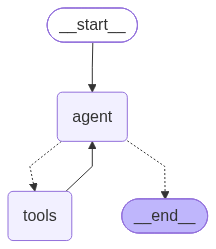

In [39]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

chatgpt = ChatOpenAI(model="gpt-4o", temperature=0, api_key=Openai_key)

financial_analyst = create_react_agent(model=chatgpt,
                                       tools=tools,
                                       state_modifier=SYS_PROMPT)
financial_analyst

## Test Financial Analyst ReAct Agent

In [40]:
from IPython.display import display, Markdown

for event in financial_analyst.stream(
    {"messages": [HumanMessage(content="Tell me some stocks I could potentially invest in")]},
    stream_mode='values' #returns full agent state with all messages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
display(Markdown(event["messages"][-1].content))

================================ Human Message =================================

Tell me some stocks I could potentially invest in
================================== Ai Message ==================================
Tool Calls:
  get_general_market_data (call_rhRG1Z3nnvWpP2RqkEI8e9It)
 Call ID: call_rhRG1Z3nnvWpP2RqkEI8e9It
  Args:
================================= Tool Message =================================
Name: get_general_market_data

Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:

Most actively traded stocks:

|    | symbol   | name                            |   price |     change |   percent_change |    volume |    open |     high |      low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | curren

Here are some stocks that are currently active in the market and might be worth considering for investment. Please remember to do your own research before making any investment decisions.

### Most Actively Traded Stocks
1. **American Airlines Group, Inc. (AAL)**
   - Price: \$14.98
   - Change: -3.97%
   - Volume: 176,722,073

2. **Netflix, Inc. (NFLX)**
   - Price: \$68.95
   - Change: -7.26%
   - Volume: 141,231,076

3. **NVIDIA Corporation (NVDA)**
   - Price: \$202.81
   - Change: -2.21%
   - Volume: 138,213,660

### Top Price Gainers
1. **ITG, Inc. (ITG)**
   - Price: \$12.14
   - Change: +14.74%
   - Volume: 696,603

2. **Lucid Group, Inc. (LCID)**
   - Price: \$7.36
   - Change: +13.93%
   - Volume: 47,786,233

3. **Sweetgreen, Inc. (SG)**
   - Price: \$7.08
   - Change: +13.83%
   - Volume: 12,866,202

### Top Price Losers
1. **Home Bancorp, Inc. (HBCP)**
   - Price: \$69.31
   - Change: -2.94%
   - Volume: 90,863

2. **MACOM Technology Solutions Holdings (MTSI)**
   - Price: \$267.36
   - Change: -2.95%
   - Volume: 1,749,394

3. **KB Home (KBH)**
   - Price: \$56.10
   - Change: -2.96%
   - Volume: 876,424

These stocks are showing significant activity in the market. However, it's crucial to analyze their fundamentals, market conditions, and your investment strategy before proceeding.

In [41]:
for event in financial_analyst.stream(
    {"messages": [HumanMessage(content="Tell me how is Nvidia doing right now as a company and could I potentially invest in it?")]},
    stream_mode='values' #returns full agent state with all messages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
display(Markdown(event["messages"][-1].content))

================================ Human Message =================================

Tell me how is Nvidia doing right now as a company and could I potentially invest in it?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (call_aTTwFacftD6rVfdkz3ufRLqu)
 Call ID: call_aTTwFacftD6rVfdkz3ufRLqu
  Args:
    stock_name: Nvidia
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name        |     cik |
|---:|:---------|:------------|--------:|
|  0 | NVDA     | NVIDIA CORP | 1045810 |
================================== Ai Message ==================================
Tool Calls:
  get_stock_price_metrics (call_OGMTMNOLfDFZnnEFPy9y7dzJ)
 Call ID: call_OGMTMNOLfDFZnnEFPy9y7dzJ
  Args:
    stock_ticker: NVDA
  get_stock_fundamental_indicator_metrics (call_59YJbRI0lfXWmeddRN4zYMy4)
 Call I

It seems there was an issue retrieving the latest data for Nvidia (symbol: NVDA). Unfortunately, I couldn't access the stock price metrics, fundamental indicators, or recent news at this moment due to technical errors.

However, Nvidia is a well-known company in the technology sector, particularly recognized for its graphics processing units (GPUs) and AI technology. It's generally considered a strong player in the market, but I recommend checking the latest stock performance and news from a reliable financial news source or platform.

Before making any investment decisions, it's crucial to conduct thorough research and consider consulting with a financial advisor to understand the risks and potential of investing in Nvidia or any other stock.

In [43]:
def call_financial_analyst_agent(query, verbose=False):

    for event in financial_analyst.stream(
        {"messages": [HumanMessage(content=query)]},
        stream_mode='values' #returns full agent state with all messages including updates
    ):
        if verbose:
            event["messages"][-1].pretty_print()

    print('\n\nFinal Response:\n')
    display(Markdown(event["messages"][-1].content))

In [44]:
call_financial_analyst_agent(query="Do a comparative analysis between Nvidia and Intel and recommend which one to buy or avoid?",
                             verbose=True)

================================ Human Message =================================

Do a comparative analysis between Nvidia and Intel and recommend which one to buy or avoid?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (call_jZYKZwNknE0KmKbVqLSLsaq5)
 Call ID: call_jZYKZwNknE0KmKbVqLSLsaq5
  Args:
    stock_name: Nvidia
  get_stock_ticker_symbol (call_iuNTDudwZdapYVMsoOCfvAPf)
 Call ID: call_iuNTDudwZdapYVMsoOCfvAPf
  Args:
    stock_name: Intel
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name                                                           |     cik |
|---:|:---------|:---------------------------------------------------------------|--------:|
|  0 | INTC     | INTEL CORP                                                     |   50863 |
|  1 | OCTV     | O

It seems there was an issue retrieving the fundamental and price metrics for Nvidia (NVDA) and Intel (INTC) due to missing credentials and unexpected errors. Unfortunately, without this data, I can't provide a detailed comparative analysis at this moment.

However, I can offer some general advice:

1. **Nvidia (NVDA)**: Known for its strong position in the graphics processing unit (GPU) market, Nvidia has been a leader in AI and gaming technologies. The company's growth prospects are often tied to advancements in AI, gaming, and data centers.

2. **Intel (INTC)**: As a major player in the semiconductor industry, Intel has been focusing on expanding its manufacturing capabilities and catching up in the GPU market. Intel's performance is often linked to its ability to innovate and compete with other semiconductor companies.

### Recommendation
- **Nvidia**: If you're looking for growth potential, especially in AI and gaming, Nvidia might be a more attractive option. However, it often trades at higher valuations.
- **Intel**: If you prefer a more established company with a focus on dividends and manufacturing expansion, Intel could be a better choice.

I recommend doing further research and considering your investment goals and risk tolerance before making a decision. If you have access to financial data platforms, you might want to check the latest financial metrics and news for both companies.

In [45]:
call_financial_analyst_agent(query="Is Intel having any issues of late, could it still be a good buy?",
                    verbose=True)

================================ Human Message =================================

Is Intel having any issues of late, could it still be a good buy?
================================== Ai Message ==================================

To provide you with a comprehensive answer regarding Intel's current situation and whether it might be a good buy, I'll look into the latest news about Intel, its stock price performance, and fundamental indicators. This will give us a clearer picture of any recent issues and its overall financial health.

Let me gather this information for you.
Tool Calls:
  get_stock_ticker_symbol (call_w1jSvvXI11usjBHZhRT5T3Co)
 Call ID: call_w1jSvvXI11usjBHZhRT5T3Co
  Args:
    stock_name: Intel
  get_general_market_data (call_whceGQqCF63k0BhQFgvSXrum)
 Call ID: call_whceGQqCF63k0BhQFgvSXrum
  Args:
================================= Tool Message =================================
Name: get_general_market_data

Here's some detailed information of the stock market which inclu

Here's a summary of the current situation for Intel Corporation (symbol: INTC):

### Recent News
- **Intel Cancels Plans for Larrabee Graphics Chip**: This headline suggests a significant strategic shift or challenge in Intel's graphics division. However, the date of this news is quite old (2009), and it may not reflect the current situation.

### Stock Price Performance
Unfortunately, I encountered an error while retrieving the latest stock price metrics for Intel. However, based on the general market data, Intel's stock is currently trading at \$95.04, with a recent change of -\$1.94, indicating a slight decline of about 2%.

### Fundamental Indicators
I was unable to retrieve the latest fundamental indicators due to a missing credential error. However, based on the general market data, Intel has a forward P/E ratio of 58.9, which is relatively high, suggesting that the stock might be overvalued compared to its earnings expectations.

### Market Position
Intel is among the most actively traded stocks, indicating strong investor interest. However, the recent price decline and high P/E ratio might be points of concern.

### Conclusion
Intel appears to be facing some challenges, as indicated by the recent price decline and high valuation metrics. While it remains a significant player in the semiconductor industry, potential investors should consider these factors and conduct further research to assess the company's strategic direction and financial health before making investment decisions.

If you have any specific questions or need further assistance, feel free to ask!

In [46]:
call_financial_analyst_agent(query="Give me the Market Cap, PE Ratio, Revenue per share for Microsoft",
                             verbose=False)



Final Response:



It seems there is an issue with retrieving the fundamental indicator metrics for Microsoft (symbol: MSFT) due to a missing API key. Unfortunately, I am unable to provide the Market Cap, PE Ratio, and Revenue per share at this moment.

I recommend checking a reliable financial news website or platform like Yahoo Finance or Bloomberg for the most up-to-date information on Microsoft's financial metrics. If you have any other questions or need assistance with something else, feel free to ask!

In [47]:
call_financial_analyst_agent(query="Do a price analysis for Apple and give me some insights from it",
                             verbose=False)



Final Response:



It seems there is an issue retrieving the stock price metrics for Apple Inc. (AAPL) at the moment. This might be a temporary glitch. Please try again later or let me know if there's anything else I can assist you with!